# Week 4 — Embeddings, Similarity & Modalities
### Understanding How Models Represent Meaning Geometrically

<a href="https://colab.research.google.com/github/tulane-intro-ai-engineering/main/blob/main/lectures/week4_embeddings_similarity.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
</a>

---

### 🎯 Learning Objectives
By the end of this lecture, you will be able to:
- Explain what an **embedding** is and why it matters in AI systems.
- Compute and visualize **cosine similarity** between embeddings.
- Compare **keyword vs. semantic search** and explain why embeddings outperform literal text matching.
- Understand the idea of **multimodal embeddings** (images & text in the same space).
- Interpret how embeddings fit into the **Unifying System Diagram (v3)** of LLM pipelines.


In [1]:
# @title Setup (Run this first)
!git clone -q https://github.com/tulane-intro-ai-engineering/main.git
import sys; sys.path.append('/content/main')
from course_utils import lab4_setup, show_mermaid
lab4_setup()
print("✅ Environment ready!")

Enter your OpenAI API key. It will only live in this Colab runtime.
OpenAI API key: ··········
✅ API key set.
✅ Environment ready!


## 🌟 Motivating Example — "Meaning Beyond Words"

Imagine searching for *"heart doctor"* in two systems:

- **Keyword Search**: looks for literal matches of words.
- **Semantic Search**: uses vector embeddings of meaning.

Let’s test it.


In [2]:
# @title Example: Keyword vs. Semantic Meaning
from openai import OpenAI
import numpy as np

client = OpenAI()

query = "heart doctor"
docs = [
    "A cardiologist treats heart disease.",
    "This is about engines.",
    "Nutrition and exercise matter.",
]

# Keyword search baseline
keyword_hits = [d for d in docs if any(w in d.lower() for w in query.split())]

# Semantic search (embeddings + cosine)
def cosine(a,b): return np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))
q_embed = client.embeddings.create(input=query, model="text-embedding-3-small").data[0].embedding
doc_embeds = [client.embeddings.create(input=d, model="text-embedding-3-small").data[0].embedding for d in docs]
sims = [cosine(q_embed, e) for e in doc_embeds]
ranked = [x for _,x in sorted(zip(sims, docs), reverse=True)]

print("🔹 Keyword search:", keyword_hits)
print("🔸 Semantic search:", ranked[:2])


🔹 Keyword search: ['A cardiologist treats heart disease.']
🔸 Semantic search: ['A cardiologist treats heart disease.', 'This is about engines.']


**Reflection:** Why did the semantic search succeed when keyword search failed?  
> Hint: embeddings capture *conceptual similarity*, not literal overlap.


## 🧮 How Does Geometry Capture Meaning?

Embeddings turn words or sentences into **vectors** in high-dimensional space.  
Cosine similarity measures their *angle* rather than distance:

$$
\text{similarity}(A, B) = \frac{A \cdot B}{\|A\|\,\|B\|}
$$

Two vectors pointing in the same direction (even if one is longer) mean **similar meaning**.


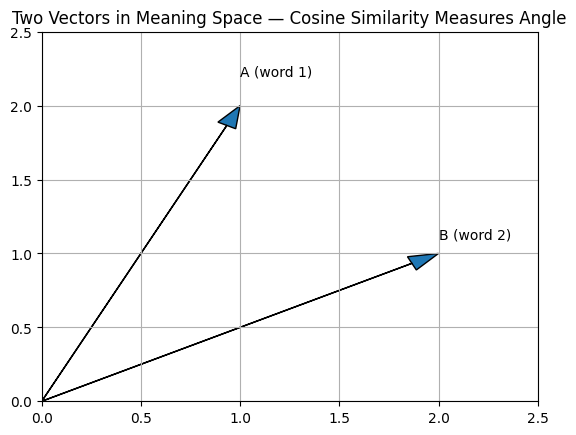

In [3]:
# @title Visualizing Cosine Similarity in 2D
import matplotlib.pyplot as plt

A = np.array([1, 2])
B = np.array([2, 1])
plt.arrow(0,0,A[0],A[1],head_width=0.1,length_includes_head=True,label='A')
plt.arrow(0,0,B[0],B[1],head_width=0.1,length_includes_head=True,label='B')
plt.xlim(0,2.5); plt.ylim(0,2.5)
plt.text(1,2.2,'A (word 1)',fontsize=10)
plt.text(2,1.1,'B (word 2)',fontsize=10)
plt.title("Two Vectors in Meaning Space — Cosine Similarity Measures Angle")
plt.grid(True)
plt.show()


## 🧭 Exploring Neighborhoods in Embedding Space

Let's see how similar various short phrases are to one another.


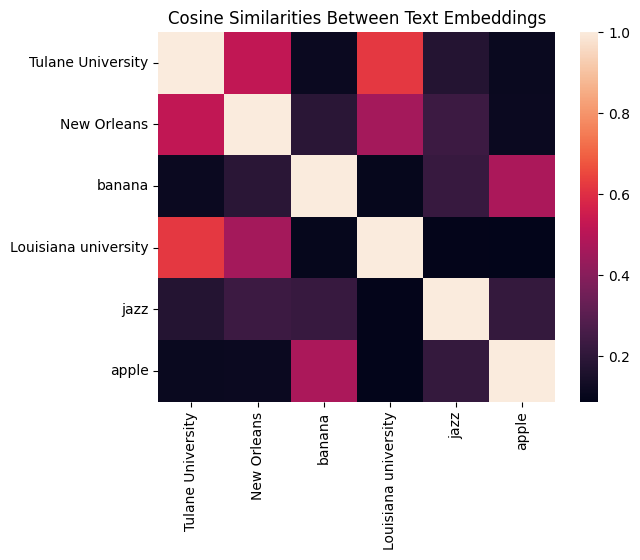

In [4]:
# @title Pairwise Cosine Similarity Heatmap
import seaborn as sns
texts = ["Tulane University", "New Orleans", "banana", "Louisiana university", "jazz", "apple"]
embeddings = [client.embeddings.create(input=t, model="text-embedding-3-small").data[0].embedding for t in texts]

cosine = lambda a,b: np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))
sim_matrix = np.zeros((len(texts), len(texts)))

for i,a in enumerate(embeddings):
    for j,b in enumerate(embeddings):
        sim_matrix[i,j] = cosine(a,b)

sns.heatmap(sim_matrix, annot=False, xticklabels=texts, yticklabels=texts)
plt.title("Cosine Similarities Between Text Embeddings")
plt.show()


**Discussion:**  
Which pairs are most similar? Are there any surprises?  
Why might “Tulane University” and “New Orleans” be nearby in vector space?


## 🔍 Keyword vs. Semantic Search — Hands-On

Now, let’s compare how **keyword search** and **embedding-based search** behave.

You’ll fill in parts of the function below.


In [ ]:
# @title TODO: Implement Semantic Search
def semantic_search(query, docs, model="text-embedding-3-small"):
    """Return top 2 most similar docs."""
    # TODO:
    # 1. Compute query embedding
    # 2. Compute embeddings for each doc
    # 3. Compute cosine similarity for each
    # 4. Sort by similarity and return top 2 docs
    raise NotImplementedError("Fill in the steps above.")

query = "music in Louisiana"
docs = [
    "Tulane University is located in New Orleans.",
    "Jazz music was born in New Orleans.",
    "Crawfish season peaks in early spring.",
    "AI models learn from data patterns, not logic rules."
]

print(semantic_search(query, docs))


## ⚖️ Cosine vs Euclidean Distance

Let’s visualize how **cosine similarity** and **Euclidean distance** can rank pairs differently.


In [5]:
# @title Visual Comparison
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import numpy as np

X = np.array([[1,0],[0.5,0.5],[0,1]])
cos_sim = cosine_similarity(X)
euc_dist = euclidean_distances(X)

print("Cosine similarity matrix:\n", cos_sim)
print("\nEuclidean distance matrix:\n", euc_dist)


Cosine similarity matrix:
 [[1.         0.70710678 0.        ]
 [0.70710678 1.         0.70710678]
 [0.         0.70710678 1.        ]]

Euclidean distance matrix:
 [[0.         0.70710678 1.41421356]
 [0.70710678 0.         0.70710678]
 [1.41421356 0.70710678 0.        ]]


**Think:** Which metric better captures *meaning* when magnitudes differ but directions align?


## 🖼️ Multimodal Embeddings — Shared Spaces for Text & Images

Modern models like **CLIP** learn embeddings where **images and text** coexist in one space.

This allows tasks like:
- “Find the picture that best matches this caption.”  
- “Find captions describing this image.”

Even without image data here, we can simulate the concept:


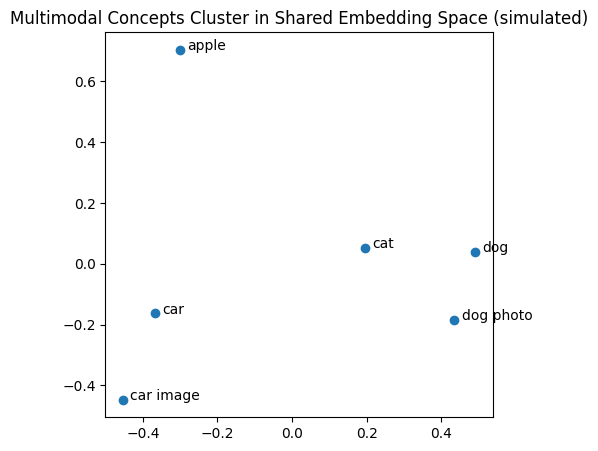

In [6]:
# @title Simulated CLIP-style Embedding Space (toy example)
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

concepts = ["dog", "cat", "car", "apple", "dog photo", "car image"]
embeds = [client.embeddings.create(input=t, model="text-embedding-3-small").data[0].embedding for t in concepts]

pca = PCA(n_components=2)
points = pca.fit_transform(embeds)
plt.figure(figsize=(5,5))
plt.scatter(points[:,0], points[:,1])
for i,txt in enumerate(concepts):
    plt.text(points[i,0]+0.02, points[i,1], txt)
plt.title("Multimodal Concepts Cluster in Shared Embedding Space (simulated)")
plt.show()


## 🧩 Unifying Diagram v3 — Adding the Embedding Store

Below is the system diagram showing where embeddings fit within the LLM pipeline.


In [7]:
# @title Unifying Diagram v3
show_mermaid("""
graph TD
    subgraph User Interaction
    U["Users<br/>Queries / Inputs"]:::user --> IH["Input Handling<br/>• Formatting<br/>• Validation<br/>• Safety Filters"]:::process
    end

    subgraph Prompt & Control
    IH --> PC("Prompt / Control<br/>• Instructions<br/>• Examples<br/>• Constraints<br/>• Params"):::control
    end

    subgraph Tools & Augmentation
    PC --> RAG{"Retrieval (RAG)<br/>• Embeddings<br/>• Vector Store<br/>• Top-k Search"}:::tool
    end

    subgraph Core LLM
    RAG --> LLM["LLM (Model)<br/>• Next-token probs<br/>• Sampling"]:::model
    PC --> LLM
    end

    subgraph Output & Monitoring
    LLM --> OP["Output Processing<br/>• Formatting<br/>• Citations<br/>• Trust Signals"]:::output --> O("Final Output"):::output
    O --> LM["Logging & Monitoring<br/>• Prompts & Responses<br/>• Metrics<br/>• Drift Detection"]:::monitor
    end
""")


## 🧠 Concept Check

> Which metric do we usually use to measure similarity between embeddings?  


In [8]:
# @title Concept Check
answer = "cosine"
print("✅ Correct!" if "cosine" in answer.lower() else "❌ Try again.")

✅ Correct!


<details>
<summary>📘 Instructor Notes</summary>

**Day 1:**
- Review Lab 3 results (pipelines).
- Introduce embeddings via motivating example.
- Cover math of cosine similarity & visualization (heatmap activity).

**Day 2:**
- Explore semantic vs. keyword search with code.
- Introduce multimodal embeddings & Unifying Diagram v3.
- Connect to next week’s topic (RAG).

**Discussion Prompts:**
- Why is “meaning” geometric?
- How could embedding drift affect downstream tasks?
- What non-text data could we embed?

</details>
